# Natural Language Processing Classification Project

This notebook is a complete beginner-friendly NLP classification project.

The goal is to classify text documents into two categories:

- hockey
- space

This project covers the full machine learning workflow:

- loading text data
- exploring the dataset
- cleaning text
- converting text into numbers
- training classification models
- evaluating models
- comparing CountVectorizer and TF-IDF
- making predictions on new text

Interview focus: in NLP, text must be converted into numerical features before it can be used by machine learning models.

## 1. Import Libraries

These libraries are used for data handling, text cleaning, vectorization, modelling, and evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re

from nltk.corpus import stopwords

from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.pipeline import Pipeline

## 2. Download Stopwords

Stopwords are common words such as "the", "is", and "and". In many NLP projects, they are removed because they usually carry less useful meaning.

In [2]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nguye\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## 3. Load Dataset

We use the `fetch_20newsgroups` dataset from scikit-learn.

The dataset may take a few minutes to download the first time. After it is downloaded once, it is usually cached and loads faster later.

If this cell takes too long or fails because of internet issues, use the small backup dataset in the next section.

In [3]:
categories = [
    "rec.sport.hockey",
    "sci.space"
]

try:
    dataset = fetch_20newsgroups(
        subset="all",
        categories=categories,
        remove=("headers", "footers", "quotes")
    )

    df = pd.DataFrame({
        "text": dataset.data,
        "target": dataset.target
    })

    target_names = dataset.target_names
    print("Dataset loaded successfully")
    print("Target names:", target_names)

except Exception as e:
    print("Could not download the dataset. Using a small backup dataset instead.")
    print("Error:", e)

    texts = [
        "The hockey team won the match after a great goal",
        "The player scored a goal in the final period",
        "The coach discussed the hockey strategy before the game",
        "The team trained hard before the championship",
        "NASA launched a spacecraft into orbit",
        "The telescope captured images of distant galaxies",
        "Scientists studied planets and stars in space",
        "The rocket mission explored the surface of Mars"
    ]

    labels = [0, 0, 0, 0, 1, 1, 1, 1]
    target_names = ["rec.sport.hockey", "sci.space"]

    df = pd.DataFrame({
        "text": texts,
        "target": labels
    })

df.head(10)

Dataset loaded successfully
Target names: ['rec.sport.hockey', 'sci.space']


,text,target
0,"\n\n\n\n\n\nWell, I guess I'm left wondering j...",1
1,"\n\n\n\n\tI think that you are incorrect, Roge...",0
2,"Forwarded from Neal Ausman, Galileo Mission Di...",1
3,\nPierre Turgeon of the Islanders,0
4,,0
5,u920496@daimi.aau.dk (Hans Erik Martino Hansen...,1
6,"\n""I hold that space cannot be curved, for the...",1
7,"\nClimbers regard 8000 metres and up as ""The D...",1
8,\nIf you've got a good propulsion system that'...,1
9,I haven't seen anyone post this so I will do t...,0


## 4. Explore the Dataset

Before training a model, always inspect the dataset size, target distribution, and a few examples.

In [4]:
df.shape

(1986, 2)

In [5]:
df["target"].value_counts()

target
0    999
1    987
Name: count, dtype: int64

In [6]:
df["target"].value_counts(normalize=True)

target
0    0.503021
1    0.496979
Name: proportion, dtype: float64

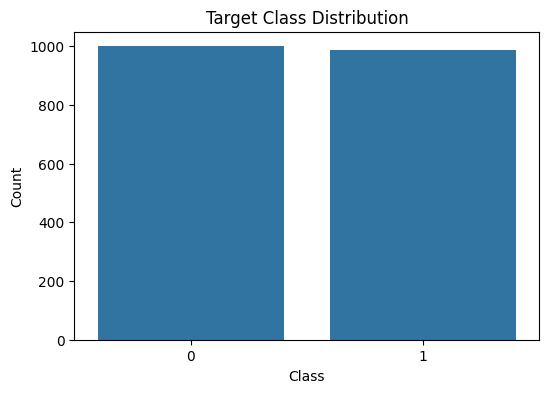

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="target")
plt.title("Target Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [8]:
# Show one example from each class
for label in sorted(df["target"].unique()):
    print("Class:", label)
    print(df[df["target"] == label]["text"].iloc[0][:500])
    print("-" * 80)

Class: 0




	I think that you are incorrect, Roger.  Patrick,
Smythe and Adams all played or coached in the league before becoming
front office types.  Hence, they did help build the league, although
they were not great players themselves.  

	I agree that a name is a name is a name, and if some people
have trouble with names that are not easily processed by the fans,
then changing them to names that are more easily processed seems like
a reasonable idea.  If we can get people in the (arena) door by bei
--------------------------------------------------------------------------------
Class: 1






Well, I guess I'm left wondering just who all the 'light fascists'
think *they* are.  Yes, I understand the issues.  I don't even
particularly care for the idea.  But am I the only one that finds the
sort of overreaction above just a *little* questionable?  You must
find things like the Moon *really* obnoxious in their pollution.

A few questions for those frothing at the mouth to ask themse

## 5. Text Cleaning

Text data is messy. We clean it before vectorization.

This function will:

- convert text to lowercase
- remove numbers
- remove punctuation
- remove extra spaces
- remove stopwords

Important: cleaning choices depend on the project. Sometimes numbers or punctuation can be useful.

In [9]:
stop_words = set(stopwords.words("english"))

def clean_text(text):
    """Clean raw text for a basic NLP classification project."""

    # Convert to string in case there are missing or non-text values
    text = str(text)

    # Lowercase
    text = text.lower()

    # Remove numbers
    text = re.sub(r"\d+", " ", text)

    # Remove punctuation and special characters
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [10]:
df["clean_text"] = df["text"].apply(clean_text)

df[["text", "clean_text", "target"]].head()

,text,clean_text,target
0,"\n\n\n\n\n\nWell, I guess I'm left wondering j...",well guess left wondering light fascists think...,1
1,"\n\n\n\n\tI think that you are incorrect, Roge...",think incorrect roger patrick smythe adams pla...,0
2,"Forwarded from Neal Ausman, Galileo Mission Di...",forwarded neal ausman galileo mission director...,1
3,\nPierre Turgeon of the Islanders,pierre turgeon islanders,0
4,,,0


## 6. Train-Test Split

We split the data before modelling.

For classification, `stratify=y` is useful because it keeps the class balance similar in both training and testing sets.

In [11]:
X_text = df["clean_text"]
y = df["target"]

# Stratify only if every class has at least 2 samples
stratify_value = y if y.value_counts().min() >= 2 else None

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=stratify_value
)

print("Training size:", X_train_text.shape)
print("Testing size:", X_test_text.shape)

Training size: (1588,)
Testing size: (398,)


## 7. Evaluation Function

This helper function calculates common classification metrics.

For NLP classification, common metrics include:

- accuracy
- precision
- recall
- F1-score

F1-score is useful when we want a balance between precision and recall.

In [12]:
def evaluate_classifier(model_name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }

## 8. CountVectorizer and Naive Bayes

CountVectorizer converts text into word counts.

Example idea:

- "hockey goal goal" becomes a vector showing that `goal` appeared 2 times.

Naive Bayes is commonly used in NLP because it works well with word-count features and sparse matrices.

In [13]:
count_nb_pipeline = Pipeline([
    ("vectorizer", CountVectorizer(max_features=5000)),
    ("model", MultinomialNB())
])

count_nb_pipeline.fit(X_train_text, y_train)

y_pred_count_nb = count_nb_pipeline.predict(X_test_text)

count_nb_result = evaluate_classifier(
    "CountVectorizer + Naive Bayes",
    y_test,
    y_pred_count_nb
)

count_nb_result

{'Model': 'CountVectorizer + Naive Bayes',
 'Accuracy': 0.9422110552763819,
 'Precision': 0.9431046780954212,
 'Recall': 0.9422110552763819,
 'F1': 0.9421749104880747}

In [14]:
print(classification_report(y_test, y_pred_count_nb, target_names=target_names, zero_division=0))

                  precision    recall  f1-score   support

rec.sport.hockey       0.92      0.96      0.94       200
       sci.space       0.96      0.92      0.94       198

        accuracy                           0.94       398
       macro avg       0.94      0.94      0.94       398
    weighted avg       0.94      0.94      0.94       398



## 9. CountVectorizer and Logistic Regression

Logistic Regression is a strong baseline for text classification.

It often performs very well with sparse text features.

In [15]:
count_lr_pipeline = Pipeline([
    ("vectorizer", CountVectorizer(max_features=5000)),
    ("model", LogisticRegression(max_iter=1000))
])

count_lr_pipeline.fit(X_train_text, y_train)

y_pred_count_lr = count_lr_pipeline.predict(X_test_text)

count_lr_result = evaluate_classifier(
    "CountVectorizer + Logistic Regression",
    y_test,
    y_pred_count_lr
)

count_lr_result

{'Model': 'CountVectorizer + Logistic Regression',
 'Accuracy': 0.9371859296482412,
 'Precision': 0.938095897195973,
 'Recall': 0.9371859296482412,
 'F1': 0.9371609396799285}

In [16]:
print(classification_report(y_test, y_pred_count_lr, target_names=target_names, zero_division=0))

                  precision    recall  f1-score   support

rec.sport.hockey       0.96      0.92      0.94       200
       sci.space       0.92      0.96      0.94       198

        accuracy                           0.94       398
       macro avg       0.94      0.94      0.94       398
    weighted avg       0.94      0.94      0.94       398



## 10. TF-IDF and Naive Bayes

TF-IDF stands for Term Frequency-Inverse Document Frequency.

It gives more weight to useful words and less weight to words that appear too often across many documents.

Simple intuition:

- common words get lower importance
- more unique and meaningful words get higher importance

In [17]:
tfidf_nb_pipeline = Pipeline([
    ("vectorizer", TfidfVectorizer(max_features=5000)),
    ("model", MultinomialNB())
])

tfidf_nb_pipeline.fit(X_train_text, y_train)

y_pred_tfidf_nb = tfidf_nb_pipeline.predict(X_test_text)

tfidf_nb_result = evaluate_classifier(
    "TF-IDF + Naive Bayes",
    y_test,
    y_pred_tfidf_nb
)

tfidf_nb_result

{'Model': 'TF-IDF + Naive Bayes',
 'Accuracy': 0.9422110552763819,
 'Precision': 0.9427488760289802,
 'Recall': 0.9422110552763819,
 'F1': 0.942188059858675}

In [18]:
print(classification_report(y_test, y_pred_tfidf_nb, target_names=target_names, zero_division=0))

                  precision    recall  f1-score   support

rec.sport.hockey       0.93      0.96      0.94       200
       sci.space       0.96      0.92      0.94       198

        accuracy                           0.94       398
       macro avg       0.94      0.94      0.94       398
    weighted avg       0.94      0.94      0.94       398



## 11. TF-IDF and Logistic Regression

This is one of the strongest traditional NLP baselines.

For many interview projects, TF-IDF plus Logistic Regression is a very good model to explain.

In [19]:
tfidf_lr_pipeline = Pipeline([
    ("vectorizer", TfidfVectorizer(max_features=5000)),
    ("model", LogisticRegression(max_iter=1000))
])

tfidf_lr_pipeline.fit(X_train_text, y_train)

y_pred_tfidf_lr = tfidf_lr_pipeline.predict(X_test_text)

tfidf_lr_result = evaluate_classifier(
    "TF-IDF + Logistic Regression",
    y_test,
    y_pred_tfidf_lr
)

tfidf_lr_result

{'Model': 'TF-IDF + Logistic Regression',
 'Accuracy': 0.9447236180904522,
 'Precision': 0.9469537788353413,
 'Recall': 0.9447236180904522,
 'F1': 0.9446649397626323}

In [20]:
print(classification_report(y_test, y_pred_tfidf_lr, target_names=target_names, zero_division=0))

                  precision    recall  f1-score   support

rec.sport.hockey       0.98      0.91      0.94       200
       sci.space       0.92      0.98      0.95       198

        accuracy                           0.94       398
       macro avg       0.95      0.94      0.94       398
    weighted avg       0.95      0.94      0.94       398



## 12. Compare All Models

Now we compare all model results in one table.

In [21]:
results = pd.DataFrame([
    count_nb_result,
    count_lr_result,
    tfidf_nb_result,
    tfidf_lr_result
])

results.sort_values(by="F1", ascending=False)

,Model,Accuracy,Precision,Recall,F1
3,TF-IDF + Logistic Regression,0.944724,0.946954,0.944724,0.944665
2,TF-IDF + Naive Bayes,0.942211,0.942749,0.942211,0.942188
0,CountVectorizer + Naive Bayes,0.942211,0.943105,0.942211,0.942175
1,CountVectorizer + Logistic Regression,0.937186,0.938096,0.937186,0.937161


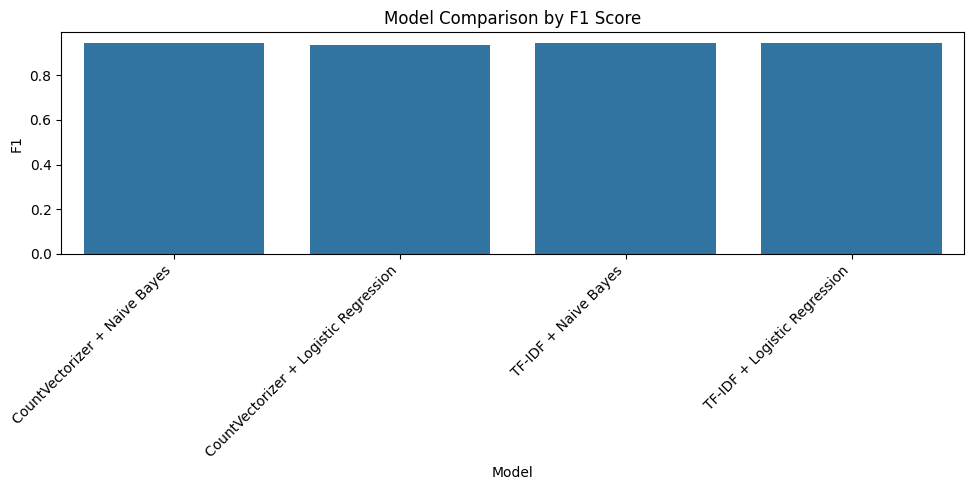

In [22]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results, x="Model", y="F1")
plt.title("Model Comparison by F1 Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 13. Confusion Matrix

A confusion matrix shows where the model is correct and where it makes mistakes.

Rows are actual labels.

Columns are predicted labels.

Best model based on F1: TF-IDF + Logistic Regression


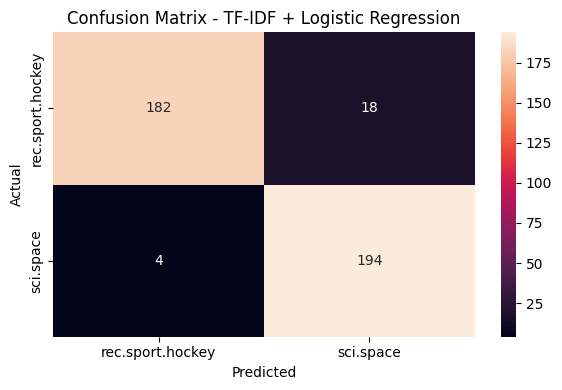

In [23]:
best_model_name = results.sort_values(by="F1", ascending=False).iloc[0]["Model"]
print("Best model based on F1:", best_model_name)

# Choose the best model predictions for confusion matrix
prediction_map = {
    "CountVectorizer + Naive Bayes": y_pred_count_nb,
    "CountVectorizer + Logistic Regression": y_pred_count_lr,
    "TF-IDF + Naive Bayes": y_pred_tfidf_nb,
    "TF-IDF + Logistic Regression": y_pred_tfidf_lr
}

best_predictions = prediction_map[best_model_name]

cm = confusion_matrix(y_test, best_predictions)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=target_names,
    yticklabels=target_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()

## 14. Inspect Important Words

For Logistic Regression, we can inspect which words are important for each class.

This improves explainability.

In [24]:
# Inspect important words from the TF-IDF + Logistic Regression model
vectorizer = tfidf_lr_pipeline.named_steps["vectorizer"]
model = tfidf_lr_pipeline.named_steps["model"]

feature_names = np.array(vectorizer.get_feature_names_out())
coefficients = model.coef_[0]

# Positive coefficients push prediction toward class 1
# Negative coefficients push prediction toward class 0
top_positive_words = feature_names[np.argsort(coefficients)[-15:]]
top_negative_words = feature_names[np.argsort(coefficients)[:15]]

print("Words pushing toward class 1:")
print(top_positive_words)

print("\nWords pushing toward class 0:")
print(top_negative_words)


Words pushing toward class 1:
['idea' 'mission' 'project' 'data' 'program' 'spacecraft' 'solar' 'sky'
 'moon' 'shuttle' 'launch' 'earth' 'orbit' 'nasa' 'space']

Words pushing toward class 0:
['game' 'hockey' 'team' 'games' 'season' 'play' 'nhl' 'players' 'espn'
 'player' 'playoffs' 'roger' 'leafs' 'playoff' 'teams']


## 15. Make Predictions on New Text

Now we test the model on new custom sentences.

In [25]:
new_texts = [
    "The hockey player scored a goal in the final match",
    "NASA launched a new rocket to study planets and stars",
    "The team won after an amazing performance on the ice",
    "The spacecraft captured images of galaxies far away"
]

new_texts_clean = [clean_text(text) for text in new_texts]

predictions = tfidf_lr_pipeline.predict(new_texts_clean)

for text, pred in zip(new_texts, predictions):
    print("Text:", text)
    print("Predicted class:", target_names[pred])
    print("-" * 80)

Text: The hockey player scored a goal in the final match
Predicted class: rec.sport.hockey
--------------------------------------------------------------------------------
Text: NASA launched a new rocket to study planets and stars
Predicted class: sci.space
--------------------------------------------------------------------------------
Text: The team won after an amazing performance on the ice
Predicted class: rec.sport.hockey
--------------------------------------------------------------------------------
Text: The spacecraft captured images of galaxies far away
Predicted class: sci.space
--------------------------------------------------------------------------------


## 16. Key Interview Explanations

### What is Bag of Words?

Bag of Words converts text into numerical vectors based on word counts.

### What is TF-IDF?

TF-IDF measures how important a word is by considering how often it appears in one document and how common it is across all documents.

### Why is the matrix sparse?

Most documents only contain a small number of words from the full vocabulary, so most values are zero.

### Why is Naive Bayes commonly used in NLP?

Naive Bayes is fast, simple, and works well with word frequency features.

### Why is Logistic Regression strong for NLP?

Logistic Regression works well with high-dimensional sparse text vectors and is easy to interpret.

### CountVectorizer vs TF-IDF

CountVectorizer uses raw word counts.

TF-IDF uses weighted word importance.

TF-IDF usually performs better when common words are less useful.

## 17. Project Summary

In this project, I learned how to build a traditional NLP text classification model.

The workflow was:

1. Load text data
2. Explore the dataset
3. Clean the text
4. Convert text into numerical vectors
5. Train Naive Bayes and Logistic Regression models
6. Compare CountVectorizer and TF-IDF
7. Evaluate the models with classification metrics
8. Use the trained model to predict new text

This project is useful for interviews because it covers the foundation of NLP before moving into more advanced techniques like word embeddings, transformers, and BERT.

## 18. Possible Improvements

Next improvements for this project:

- Use a real sentiment analysis dataset
- Add stemming or lemmatization
- Add n-grams such as bigrams and trigrams
- Tune hyperparameters with GridSearchCV
- Try LinearSVC
- Save the best model with joblib
- Build a Streamlit app where users can type text and get a prediction
- Later, compare this traditional NLP method with transformer-based models such as BERT

In [26]:
# Optional: Save the best pipeline for later use
# Uncomment this cell if you want to save the model.

# import joblib
# joblib.dump(tfidf_lr_pipeline, "nlp_text_classifier.pkl")